# Highway network

Pamietac o fine-tune:
- dropout
- batchnorm
- l2 weight decay
- learning rate
- momentum

Wsyzstko ppowinno byc optymalizowane po gridsearchu, a dodatkowo trzeba no wiadomo dopisac te hiperparametry. Uzywac Ray-Tune do tego

In [ ]:
!pip install "ray[tune]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.3/108.3 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.4/71.4 MB 12.2 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.3.0
    Uninstalling click-8.3.0:
      Successfully uninstalled click-8.3.0


In [ ]:
import numpy as np
import kagglehub
import os
from glob import glob
from PIL import Image
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [ ]:
path = kagglehub.dataset_download("ayush1220/cifar10")

Using Colab cache for faster access to the 'cifar10' dataset.


In [ ]:
# download cifar-10 dataset
path_test = path + "/cifar10/test"
path_train = path + "/cifar10/train"

In [ ]:
def load_images_from_classes(base_path, class_folders, class_to_idx,
                             flatten=True, normalize=True):
    """
    Wczytuje obrazki ze wszystkich klas w danym folderze
    """
    all_images = []
    all_labels = []

    for class_name in class_folders:
        class_path = os.path.join(base_path, class_name)
        class_idx = class_to_idx[class_name]

        # Znajdź wszystkie PNG w tym folderze
        image_files = glob(os.path.join(class_path, "*.png"))

        print(f"  📂 {class_name}: {len(image_files)} obrazków")

        # Wczytaj każdy obrazek
        for img_path in tqdm(image_files, desc=f"  Loading {class_name}",
                            leave=False, ncols=20):
            # Wczytaj obrazek
            img = Image.open(img_path)

            # Konwertuj do RGB (na wypadek RGBA lub grayscale)
            if img.mode != 'RGB':
                img = img.convert('RGB')

            # Konwertuj do numpy array
            img_array = np.array(img)

            # Normalizacja
            if normalize:
                img_array = img_array.astype('float32') / 255.0

            # Spłaszczenie jeśli potrzebne
            if flatten:
                # Z (32, 32, 3) -> (3072,)
                img_array = img_array.flatten()

            all_images.append(img_array)
            all_labels.append(class_idx)

    # Konwertuj do numpy arrays
    X = np.array(all_images)
    y = np.array(all_labels)

    print(f"  ✓ Wczytano: {X.shape}")

    return X, y

In [ ]:
def load_and_split_data(base_path, val_split=0.2):
    """
    Wczytuje dane i dzieli train na train+validation

    Args:
        base_path: ścieżka do folderu z train/test
        val_split: procent danych treningowych przeznaczonych na walidację
    """
    train_path = os.path.join(base_path, 'train')
    test_path = os.path.join(base_path, 'test')

    # Pobierz nazwy klas
    class_folders = sorted([d for d in os.listdir(train_path)
                           if os.path.isdir(os.path.join(train_path, d))])

    class_to_idx = {cls_name: idx for idx, cls_name in enumerate(class_folders)}

    print(f"🏷️  Znalezione klasy ({len(class_folders)}): {class_folders}\n")

    # Wczytaj train
    print("📥 Wczytywanie danych treningowych...")
    X_train_full, y_train_full = load_images_from_classes(
        train_path, class_folders, class_to_idx, flatten=True, normalize=True
    )

    # Wczytaj test
    print("\n📥 Wczytywanie danych testowych...")
    X_test, y_test = load_images_from_classes(
        test_path, class_folders, class_to_idx, flatten=True, normalize=True
    )

    # Podział train na train + validation
    print(f"\n✂️  Dzielenie na train/validation (val={val_split*100}%)...")

    n_total = len(X_train_full)
    n_val = int(n_total * val_split)
    n_train = n_total - n_val

    # Losowe permutacje dla mieszania danych
    indices = np.random.permutation(n_total)
    train_indices = indices[:n_train]
    val_indices = indices[n_train:]

    X_train = X_train_full[train_indices]
    y_train = y_train_full[train_indices]
    X_val = X_train_full[val_indices]
    y_val = y_train_full[val_indices]

    print(f"  ✓ Train:      {X_train.shape}")
    print(f"  ✓ Validation: {X_val.shape}")
    print(f"  ✓ Test:       {X_test.shape}")

    return X_train, y_train, X_val, y_val, X_test, y_test, class_folders

In [ ]:
X_train, y_train, X_val, y_val, X_test, y_test, class_names = load_and_split_data(path+'/cifar10')

🏷️  Znalezione klasy (10): ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

📥 Wczytywanie danych treningowych...
  📂 airplane: 5000 obrazków


  📂 automobile: 5000 obrazków


  📂 bird: 5000 obrazków


  📂 cat: 5000 obrazków


  📂 deer: 5000 obrazków


...

  📂 frog: 1000 obrazków


  📂 horse: 1000 obrazków


  📂 ship: 1000 obrazków


  📂 truck: 1000 obrazków


  ✓ Wczytano: (10000, 3072)

✂️  Dzielenie na train/validation (val=20.0%)...
  ✓ Train:      (40000, 3072)
  ✓ Validation: (10000, 3072)
  ✓ Test:       (10000, 3072)


## Definition of network

In [ ]:
class HighwayLayer(nn.Module):
    def __init__(self, size, activation=F.relu):
        super(HighwayLayer, self).__init__()
        self.activation = activation
        self.normal_layer = nn.Linear(size, size)
        self.gate_layer = nn.Linear(size, size)

    def forward(self, x):
        normal = self.activation(self.normal_layer(x))
        gate = torch.sigmoid(self.gate_layer(x))
        output = normal * gate + x * (1 - gate)
        return output


class HighwayNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.5, batch_norm=True, ):
        super(HighwayNetwork, self).__init__()

        self.input_layer = nn.Linear(input_size, hidden_size)
        self.dropout = nn.Dropout(dropout)

        self.highway_layers = nn.ModuleList([
            HighwayLayer(hidden_size) for _ in range(num_layers)
        ])

        self.output_layer = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = F.relu(self.input_layer(x))
        x = self.dropout(x)

        for highway_layer in self.highway_layers:
            x = highway_layer(x)

        output = self.output_layer(x)
        return output

### Image dataset definition

In [ ]:
class ImageDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

## Training loop

In [ ]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """Trenowanie jednej epoki"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in tqdm(train_loader, desc="Training", leave=False, ncols=80):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc


In [ ]:
def validate(model, val_loader, criterion, device):
    """Walidacja modelu"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc="Validation", leave=False, ncols=80):
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_loss = running_loss / len(val_loader)
    val_acc = 100. * correct / total

    return val_loss, val_acc

In [ ]:
def plot_training_history(history):
    """Wizualizacja historii treningu"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    epochs = range(1, len(history['train_loss']) + 1)

    # Loss
    ax1.plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    ax1.plot(epochs, history['val_loss'], 'r-', label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.legend()
    ax1.grid(True)

    # Accuracy
    ax2.plot(epochs, history['train_acc'], 'b-', label='Train Acc')
    ax2.plot(epochs, history['val_acc'], 'r-', label='Val Acc')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Training and Validation Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    print("✓ Wykres zapisany jako 'training_history.png'")
    plt.show()



🖥️  Device: cuda
  ✓ Train batches: 313
  ✓ Val batches:   79
  ✓ Test batches:  79

🏗️  Budowanie modelu Highway Network...
  Input size:        3072
  Hidden size:       512
  Highway layers:    5
  Output classes:    10
  Dropout:           0.5

🚀 ROZPOCZĘCIE TRENINGU

Epoch 1/50
--------------------------------------------------


Train Loss: 2.0886 | Train Acc: 21.07%
Val Loss:   2.0074 | Val Acc:   27.88%
✓ Nowy najlepszy model! Val Acc: 27.88%

Epoch 2/50
--------------------------------------------------


Train Loss: 2.0006 | Train Acc: 25.55%
Val Loss:   1.9334 | Val Acc:   29.76%
✓ Nowy najlepszy model! Val Acc: 29.76%

Epoch 3/50
--------------------------------------------------


Train Loss: 1.9698 | Train Acc: 26.98%
Val Loss:   1.8994 | Val Acc:   31.85%
✓ Nowy najlepszy model! Val Acc: 31.85%

Epoch 4/50
--------------------------------------------------


Train Loss: 1.9636 | Train Acc: 27.12%
Val Loss:   1.9154 | Val Acc:   31.83%

Epoch 5/50
--------------------------------------------------


...

Train Loss: 1.7980 | Train Acc: 34.08%
Val Loss:   1.8269 | Val Acc:   31.23%

Epoch 48/50
--------------------------------------------------


Train Loss: 1.7989 | Train Acc: 34.23%
Val Loss:   1.8826 | Val Acc:   30.42%

Epoch 49/50
--------------------------------------------------


Train Loss: 1.7905 | Train Acc: 35.05%
Val Loss:   1.8640 | Val Acc:   30.07%

Epoch 50/50
--------------------------------------------------


Train Loss: 1.7859 | Train Acc: 34.80%
Val Loss:   1.8309 | Val Acc:   31.76%

📊 TESTOWANIE MODELU



🎯 Final Test Accuracy: 33.38%
🎯 Best Val Accuracy:   32.60%

✓ Wykres zapisany jako 'training_history.png'


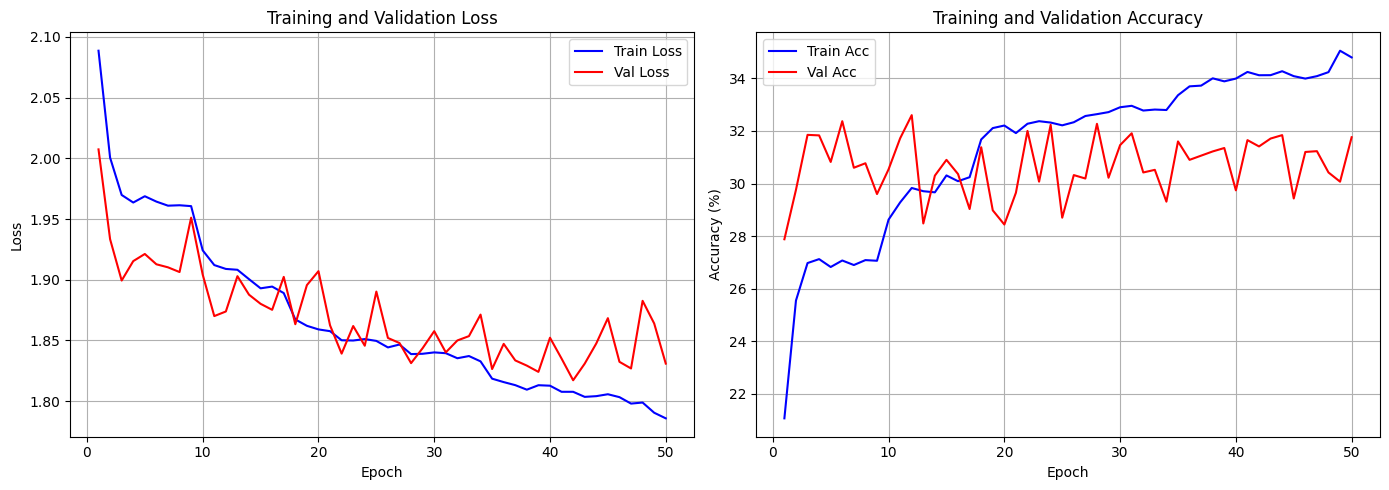


✅ TRENING ZAKOŃCZONY!
Model zapisany jako: best_highway_model.pth
Wykres zapisany jako: training_history.png


In [ ]:
BATCH_SIZE = 128
LEARNING_RATE = 0.001
NUM_EPOCHS = 50
HIDDEN_SIZE = 512
NUM_HIGHWAY_LAYERS = 5
DROPOUT = 0.5
VAL_SPLIT = 0.2
INPUT_SIZE = X_train.shape[1];
NUM_CLASSES = len(class_names)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n🖥️  Device: {device}")

train_dataset = ImageDataset(X_train, y_train)
val_dataset = ImageDataset(X_val, y_val)
test_dataset = ImageDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"  ✓ Train batches: {len(train_loader)}")
print(f"  ✓ Val batches:   {len(val_loader)}")
print(f"  ✓ Test batches:  {len(test_loader)}")

print(f"\n🏗️  Budowanie modelu Highway Network...")
print(f"  Input size:        {INPUT_SIZE}")
print(f"  Hidden size:       {HIDDEN_SIZE}")
print(f"  Highway layers:    {NUM_HIGHWAY_LAYERS}")
print(f"  Output classes:    {NUM_CLASSES}")
print(f"  Dropout:           {DROPOUT}")

model = HighwayNetwork(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_HIGHWAY_LAYERS,
    output_size=NUM_CLASSES,
    dropout=DROPOUT
).to(device)

# Loss i optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# Training loop
print("\n" + "=" * 70)
print("🚀 ROZPOCZĘCIE TRENINGU")
print("=" * 70)

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0.0

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 50)

    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

    # Validate
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    # Scheduler step
    scheduler.step(val_loss)

    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Print results
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_highway_model.pth')
        print(f"✓ Nowy najlepszy model! Val Acc: {val_acc:.2f}%")

# Test final model
print("\n" + "=" * 70)
print("📊 TESTOWANIE MODELU")
print("=" * 70)

model.load_state_dict(torch.load('best_highway_model.pth'))
test_loss, test_acc = validate(model, test_loader, criterion, device)

print(f"\n🎯 Final Test Accuracy: {test_acc:.2f}%")
print(f"🎯 Best Val Accuracy:   {best_val_acc:.2f}%")

# Plot history
print("\n" + "=" * 70)
plot_training_history(history)

print("\n" + "=" * 70)
print("✅ TRENING ZAKOŃCZONY!")
print("=" * 70)
print(f"Model zapisany jako: best_highway_model.pth")
print(f"Wykres zapisany jako: training_history.png")


# Weight visualization

In [ ]:
for m in model.modules():
  if isinstance(m, HighwayLayer):
      print(m.parameters)

<bound method Module.parameters of HighwayLayer(
  (normal_layer): Linear(in_features=512, out_features=512, bias=True)
  (gate_layer): Linear(in_features=512, out_features=512, bias=True)
)>
<bound method Module.parameters of HighwayLayer(
  (normal_layer): Linear(in_features=512, out_features=512, bias=True)
  (gate_layer): Linear(in_features=512, out_features=512, bias=True)
)>
<bound method Module.parameters of HighwayLayer(
  (normal_layer): Linear(in_features=512, out_features=512, bias=True)
  (gate_layer): Linear(in_features=512, out_features=512, bias=True)
)>
<bound method Module.parameters of HighwayLayer(
  (normal_layer): Linear(in_features=512, out_features=512, bias=True)
  (gate_layer): Linear(in_features=512, out_features=512, bias=True)
)>
<bound method Module.parameters of HighwayLayer(
  (normal_layer): Linear(in_features=512, out_features=512, bias=True)
  (gate_layer): Linear(in_features=512, out_features=512, bias=True)
)>
